# LSTM — ICU Mortality Prediction

In [7]:
import os
import sys


IS_COLAB = False

if "google.colab" in sys.modules or "COLAB_RELEASE_TAG" in os.environ:
    print("Status: Running on Google Colab")
    IS_COLAB = True
    from google.colab import drive

    drive.mount("/content/drive")
else:
    print("Status: Running Locally")

Mounted at /content/drive


In [16]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader
from torch.utils.data import Dataset


STATIC_COLS = ["age", "height_cm", "weight_kg", "gender"]
TS_COLS = [
    "Albumin",
    "ALP",
    "ALT",
    "AST",
    "Bilirubin",
    "BUN",
    "Cholesterol",
    "Creatinine",
    "DiasABP",
    "FiO2",
    "GCS",
    "Glucose",
    "HCO3",
    "HCT",
    "HR",
    "K",
    "Lactate",
    "Mg",
    "MAP",
    "MechVent",
    "Na",
    "NIDiasABP",
    "NIMAP",
    "NISysABP",
    "PaCO2",
    "PaO2",
    "pH",
    "Platelets",
    "RespRate",
    "SaO2",
    "SysABP",
    "Temp",
    "TroponinI",
    "TroponinT",
    "Urine",
    "WBC",
]
DATA_DIR = "./drive/MyDrive/data"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch {torch.__version__}  |  device: {DEVICE}")

PyTorch 2.10.0+cu128  |  device: cuda


## 1 — Load prepared data

In [17]:
df_a = pd.read_parquet(os.path.join(DATA_DIR, "set_a_table_imputed.parquet"))
df_b = pd.read_parquet(os.path.join(DATA_DIR, "set_b_table_imputed.parquet"))
df_c = pd.read_parquet(os.path.join(DATA_DIR, "set_c_table_imputed.parquet"))

print(f"Set A: {df_a.shape}  |  Set B: {df_b.shape}  |  Set C: {df_c.shape}")
print(
    f"Positive rate — A: {df_a.groupby('PatientID')['in_hospital_death'].first().mean():.3f}",
    end="  ",
)
print(
    f"B: {df_b.groupby('PatientID')['in_hospital_death'].first().mean():.3f}", end="  "
)
print(f"C: {df_c.groupby('PatientID')['in_hospital_death'].first().mean():.3f}")

Set A: (192000, 43)  |  Set B: (192000, 43)  |  Set C: (192000, 43)
Positive rate — A: 0.139  B: 0.142  C: 0.146


## 2 — Build tensors  (N_patients × 48 × 41)

In [18]:
# Feature columns fed into the LSTM at every hourly step:
#   timestamp (1-48) + all TS params + static demographics = 1 + 36 + 4 = 41
FEAT_COLS = ["timestamp", *TS_COLS, *STATIC_COLS]
print(
    f"Input features: {len(FEAT_COLS)}  (1 timestamp + {len(TS_COLS)} TS + {len(STATIC_COLS)} static)"
)


def build_tensors(df: pd.DataFrame) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Convert a 48-row-per-patient DataFrame into:
      X : FloatTensor (N_patients, 48, n_features) — sorted by PatientID then timestamp
      y : FloatTensor (N_patients,)
    """
    df = df.sort_values(["PatientID", "timestamp"]).reset_index(drop=True)
    n = df["PatientID"].nunique()
    X = df[FEAT_COLS].to_numpy(dtype=np.float32).reshape(n, 48, len(FEAT_COLS))
    y = (
        df.groupby("PatientID", sort=True)["in_hospital_death"]
        .first()
        .to_numpy(dtype=np.float32)
    )
    return torch.from_numpy(X), torch.from_numpy(y)


X_train, y_train = build_tensors(df_a)
X_val, y_val = build_tensors(df_b)
X_test, y_test = build_tensors(df_c)

print(f"Train — X: {tuple(X_train.shape)}  positives: {y_train.mean():.3f}")
print(f"Val   — X: {tuple(X_val.shape)}    positives: {y_val.mean():.3f}")
print(f"Test  — X: {tuple(X_test.shape)}   positives: {y_test.mean():.3f}")

Input features: 41  (1 timestamp + 36 TS + 4 static)
Train — X: (4000, 48, 41)  positives: 0.139
Val   — X: (4000, 48, 41)    positives: 0.142
Test  — X: (4000, 48, 41)   positives: 0.146


## 3 — Dataset & DataLoader

In [19]:
class ICUTableDataset(Dataset):
    def __init__(self, X: torch.Tensor, y: torch.Tensor):
        self.X = X
        self.y = y

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.X[idx], self.y[idx]


BATCH_SIZE = 64

train_loader = DataLoader(
    ICUTableDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)
val_loader = DataLoader(
    ICUTableDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    ICUTableDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False
)

print(
    f"Train batches: {len(train_loader)}  |  Val: {len(val_loader)}  |  Test: {len(test_loader)}"
)

Train batches: 62  |  Val: 63  |  Test: 63


## 4 — Model definition

In [20]:
class SimpleICULSTM(nn.Module):
    def __init__(
        self,
        input_size: int = 41,
        hidden_size: int = 32,
        num_layers: int = 1,
        dropout: float = 0.4,
        strategy: str = "last",
        bidirectional: bool = False,
    ):
        """
        Lightweight LSTM for small clinical datasets.

        strategy options
        ----------------
        'last'        — hidden state at the final time step
        'global_pool' — mean-pool and max-pool concatenated (2x hidden dim)

        bidirectional=True doubles the LSTM output width; fc_in is adjusted
        automatically so the same linear head always maps to a single logit.
        """
        super().__init__()
        self.strategy = strategy
        self.bidirectional = bidirectional
        D = 2 if bidirectional else 1  # direction multiplier

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        self.dropout = nn.Dropout(dropout)

        # global_pool concatenates mean + max → twice the width
        fc_in = D * hidden_size * 2 if strategy == "global_pool" else D * hidden_size
        self.fc = nn.Linear(fc_in, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x   : (Batch, 48, input_size)
        # out : (Batch, 48, D*hidden_size)
        out, _ = self.lstm(x)

        if self.strategy == "last":
            rep = out[:, -1, :]  # (B, D*H)
        elif self.strategy == "global_pool":
            rep = torch.cat([out.mean(dim=1), out.max(dim=1)[0]], dim=-1)  # (B, 2*D*H)
        else:
            raise ValueError(
                f"strategy must be 'last' or 'global_pool', got {self.strategy!r}"
            )

        logits = self.fc(self.dropout(rep))  # (B, 1)
        return logits.squeeze(-1)  # (B,)


# Quick sanity check — verify output shapes for all 4 configs
_dummy = torch.zeros(4, 48, 41)
for _bidir, _strat in [
    (False, "last"),
    (False, "global_pool"),
    (True, "last"),
    (True, "global_pool"),
]:
    _m = SimpleICULSTM(input_size=41, bidirectional=_bidir, strategy=_strat)
    _n = sum(p.numel() for p in _m.parameters() if p.requires_grad)
    assert _m(_dummy).shape == (4,), "output shape mismatch"
    print(f"  bidir={str(_bidir):<5}  strategy={_strat:<11}  params={_n:,}")

  bidir=False  strategy=last         params=9,633
  bidir=False  strategy=global_pool  params=9,665
  bidir=True   strategy=last         params=19,265
  bidir=True   strategy=global_pool  params=19,329


## 5 — Model configurations & training utilities

In [21]:
CONFIGS = [
    {"name": "Forward   + last", "bidirectional": False, "strategy": "last"},
    {
        "name": "Forward   + global_pool",
        "bidirectional": False,
        "strategy": "global_pool",
    },
    {"name": "Bidir     + last", "bidirectional": True, "strategy": "last"},
    {
        "name": "Bidir     + global_pool",
        "bidirectional": True,
        "strategy": "global_pool",
    },
]

MAX_EPOCHS = 150
PATIENCE = 15
LR = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 64  # already set above, repeated here for clarity

pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()]).to(DEVICE)


def evaluate(model: nn.Module, loader: DataLoader) -> tuple[float, float, np.ndarray]:
    model.eval()
    logits_all, labels_all = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            logits_all.append(model(X_b.to(DEVICE)).cpu())
            labels_all.append(y_b)
    logits = torch.cat(logits_all).numpy()
    labels = torch.cat(labels_all).numpy()
    probs = torch.sigmoid(torch.from_numpy(logits)).numpy()
    return roc_auc_score(labels, probs), average_precision_score(labels, probs), probs


def train_model(cfg: dict) -> dict:
    """Train one configuration; return a results dict."""
    model = SimpleICULSTM(
        input_size=len(FEAT_COLS),
        hidden_size=32,
        num_layers=1,
        dropout=0.4,
        strategy=cfg["strategy"],
        bidirectional=cfg["bidirectional"],
    ).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_val_auroc = 0.0
    best_epoch = 0
    best_state = None
    patience_count = 0
    history = []

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        total_loss = 0.0
        for X_b, y_b in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_b.to(DEVICE)), y_b.to(DEVICE))
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(y_b)

        val_auroc, val_auprc, _ = evaluate(model, val_loader)
        avg_loss = total_loss / len(train_loader.dataset)
        history.append(
            {
                "epoch": epoch,
                "loss": avg_loss,
                "val_auroc": val_auroc,
                "val_auprc": val_auprc,
            }
        )

        if val_auroc > best_val_auroc:
            best_val_auroc = val_auroc
            best_epoch = epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                break

    model.load_state_dict(best_state)
    return {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "best_val_auroc": best_val_auroc,
    }


print("Configurations:")
for cfg in CONFIGS:
    _m = SimpleICULSTM(
        input_size=len(FEAT_COLS),
        bidirectional=cfg["bidirectional"],
        strategy=cfg["strategy"],
    )
    _n = sum(p.numel() for p in _m.parameters() if p.requires_grad)
    print(f"  {cfg['name']:<30}  params={_n:,}")

Configurations:
  Forward   + last                params=9,633
  Forward   + global_pool         params=9,665
  Bidir     + last                params=19,265
  Bidir     + global_pool         params=19,329


## 6 — Train all 4 configurations

In [22]:
results = {}

for cfg in CONFIGS:
    print(f"\n{'─' * 56}")
    print(f"  {cfg['name']}")
    print(f"{'─' * 56}")
    print(f"  {'Epoch':>6}  {'Train loss':>10}  {'Val AuROC':>9}  {'Val AuPRC':>9}")

    res = train_model(cfg)
    results[cfg["name"]] = res

    # Print every-5-epoch snapshot from history
    for row in res["history"]:
        if row["epoch"] % 5 == 0 or row["epoch"] == 1:
            print(
                f"  {row['epoch']:>6}  {row['loss']:>10.4f}  {row['val_auroc']:>9.4f}  {row['val_auprc']:>9.4f}"
            )

    n_epochs = len(res["history"])
    print(
        f"  → stopped at epoch {n_epochs}  |  best epoch {res['best_epoch']}  val AuROC={res['best_val_auroc']:.4f}"
    )


────────────────────────────────────────────────────────
  Forward   + last
────────────────────────────────────────────────────────
   Epoch  Train loss  Val AuROC  Val AuPRC
       1      1.1778     0.7627     0.3941
       5      0.9167     0.8181     0.4660
      10      0.8024     0.8346     0.4888
      15      0.7300     0.8272     0.4841
      20      0.6581     0.8347     0.4836
      25      0.6303     0.8298     0.4794
      30      0.5552     0.8234     0.4788
  → stopped at epoch 32  |  best epoch 17  val AuROC=0.8383

────────────────────────────────────────────────────────
  Forward   + global_pool
────────────────────────────────────────────────────────
   Epoch  Train loss  Val AuROC  Val AuPRC
       1      1.1693     0.7365     0.3461
       5      0.9225     0.7875     0.3837
      10      0.8011     0.7932     0.4245
      15      0.6975     0.7975     0.4139
      20      0.5825     0.7776     0.3953
      25      0.5166     0.7594     0.3617
  → stopped at epoch

## 7 — Training curves

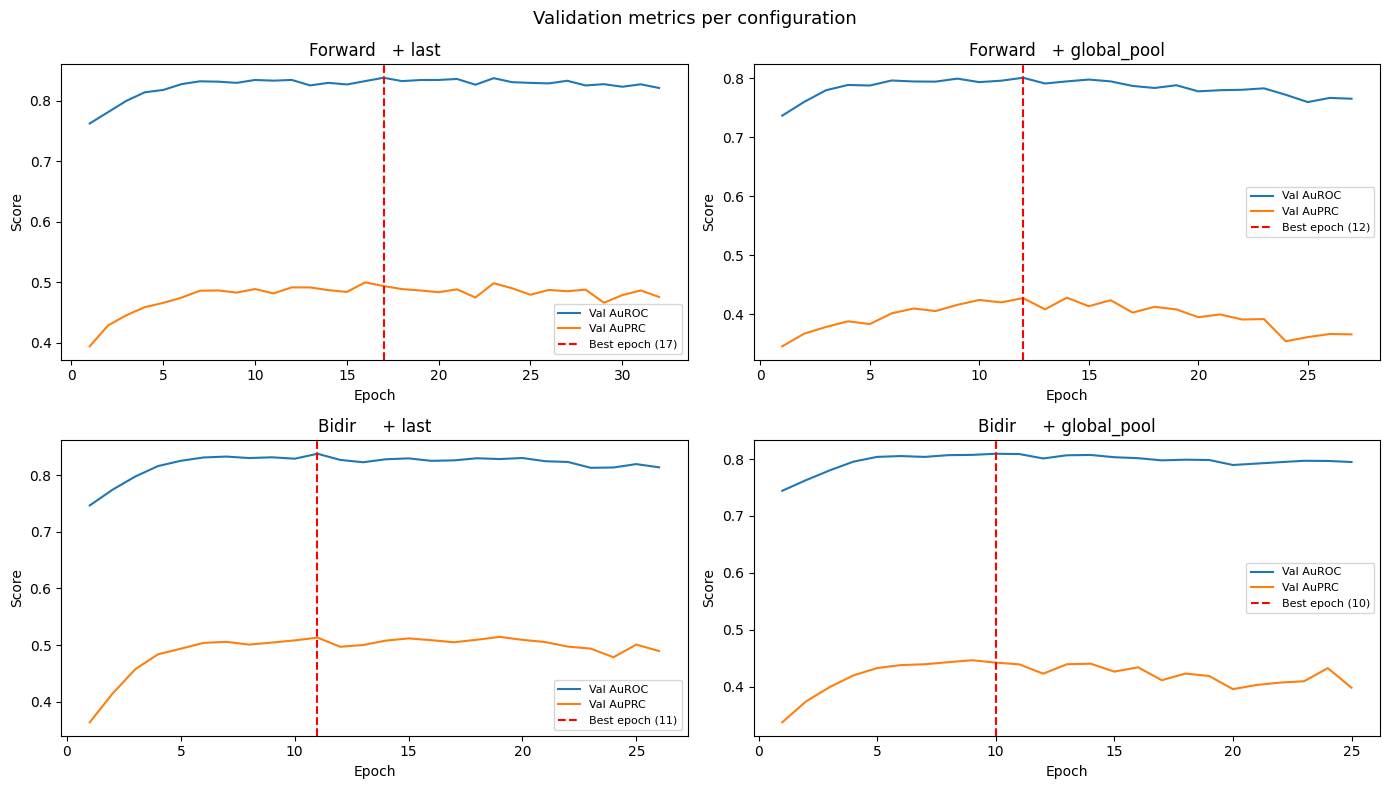

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (name, res) in zip(axes.flat, results.items()):
    hist = pd.DataFrame(res["history"])
    ax.plot(hist["epoch"], hist["val_auroc"], label="Val AuROC")
    ax.plot(hist["epoch"], hist["val_auprc"], label="Val AuPRC")
    ax.axvline(
        res["best_epoch"],
        color="red",
        linestyle="--",
        label=f"Best epoch ({res['best_epoch']})",
    )
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.legend(fontsize=8)

plt.suptitle("Validation metrics per configuration", fontsize=13)
plt.tight_layout()
plt.show()

## 8 — Validation set B comparison

In [24]:
print("=" * 58)
print(f"{'Configuration':<32}  {'Val AuROC':>9}  {'Val AuPRC':>9}")
print("-" * 58)
val_summary = []
for name, res in results.items():
    _, val_auprc, val_probs = evaluate(res["model"], val_loader)
    val_auroc = res["best_val_auroc"]
    val_summary.append({"name": name, "val_auroc": val_auroc, "val_auprc": val_auprc})
    print(f"{name:<32}  {val_auroc:>9.4f}  {val_auprc:>9.4f}")
print("=" * 58)

Configuration                     Val AuROC  Val AuPRC
----------------------------------------------------------
Forward   + last                     0.8383     0.4938
Forward   + global_pool              0.8006     0.4276
Bidir     + last                     0.8380     0.5132
Bidir     + global_pool              0.8095     0.4422


## 9 — Test set C evaluation (AuROC & AuPRC)

Configuration                       AuROC    AuPRC
----------------------------------------------------------
Forward   + last                   0.8305   0.4747
Forward   + global_pool            0.8083   0.4373
Bidir     + last                   0.8300   0.4888


Bidir     + global_pool            0.8050   0.4301


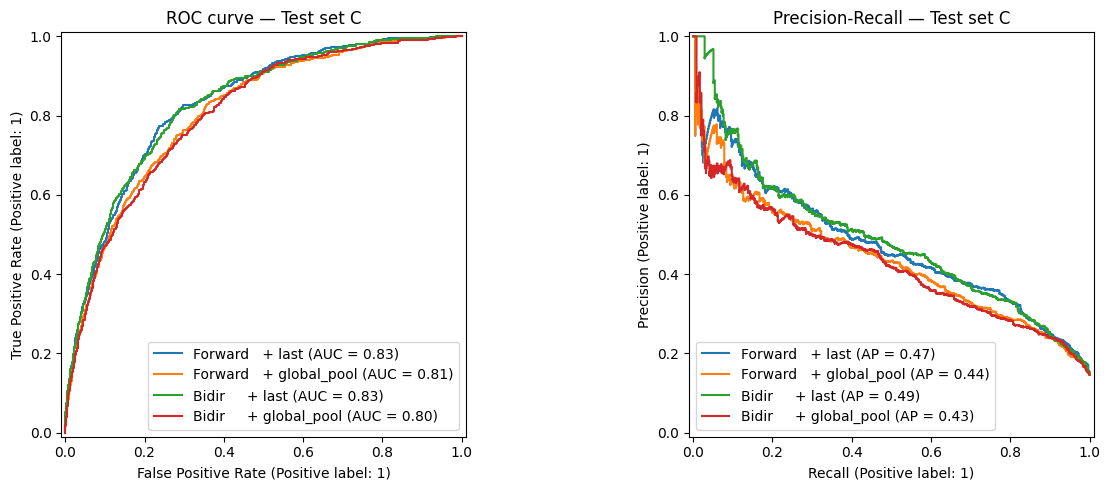

In [25]:
print("=" * 58)
print(f"{'Configuration':<32}  {'AuROC':>7}  {'AuPRC':>7}")
print("-" * 58)
test_summary = []
for name, res in results.items():
    test_auroc, test_auprc, test_probs = evaluate(res["model"], test_loader)
    test_summary.append(
        {"name": name, "auroc": test_auroc, "auprc": test_auprc, "probs": test_probs}
    )
    print(f"{name:<32}  {test_auroc:>7.4f}  {test_auprc:>7.4f}")
print("=" * 58)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for entry in test_summary:
    RocCurveDisplay.from_predictions(
        y_test.numpy(), entry["probs"], name=entry["name"], ax=axes[0]
    )
    PrecisionRecallDisplay.from_predictions(
        y_test.numpy(), entry["probs"], name=entry["name"], ax=axes[1]
    )

axes[0].set_title("ROC curve — Test set C")
axes[1].set_title("Precision-Recall — Test set C")
plt.tight_layout()
plt.show()

## 10 — SimpleTransformer definition

In [26]:
class SimpleTransformer(nn.Module):
    def __init__(
        self,
        input_dim: int = 41,
        d_model: int = 128,
        nhead: int = 4,
        num_layers: int = 1,
        dropout: float = 0.4,
    ):
        """
        Lightweight Transformer encoder for ICU time-series.

        Architecture
        ------------
        Input projection  : linear(input_dim → d_model)
        Positional encoding: learnable (1, 48, d_model) parameter
        Transformer encoder: num_layers x (4-head attention, FFN dim 256)
        Classifier head   : global-average-pool across 48 steps → linear → 1 logit
        """
        super().__init__()
        self.input_projection = nn.Linear(input_dim, d_model)

        # Learnable positional embedding — one vector per hour slot
        self.pos_embedding = nn.Parameter(torch.zeros(1, 48, d_model))
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=256,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (Batch, 48, input_dim)
        x = self.input_projection(x)  # (Batch, 48, d_model)
        x = x + self.pos_embedding  # inject positional information

        x = self.transformer_encoder(x)  # (Batch, 48, d_model)

        x = x.mean(dim=1)  # global average pool → (Batch, d_model)
        logits = self.classifier(self.dropout(x))  # (Batch, 1)
        return logits.squeeze(-1)  # (Batch,)


tf_model = SimpleTransformer(input_dim=len(FEAT_COLS)).to(DEVICE)
n_params = sum(p.numel() for p in tf_model.parameters() if p.requires_grad)
print(tf_model)
print(f"\nTrainable parameters: {n_params:,}")

SimpleTransformer(
  (input_projection): Linear(in_features=41, out_features=128, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.4, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.4, inplace=False)
        (dropout2): Dropout(p=0.4, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.4, inplace=False)
  (classifier): Linear(in_features=128, out_features=1, bias=True)
)

Trainable parameters: 144,129


## 11 — Train SimpleTransformer & evaluate

 Epoch  Train loss  Val AuROC  Val AuPRC
--------------------------------------------
     1      1.1503     0.7407     0.3597
     5      0.9365     0.7938     0.4396
    10      0.8325     0.8115     0.4449
    15      0.7407     0.7984     0.4229
    20      0.6329     0.7934     0.4268
    25      0.5457     0.7882     0.3910

Early stop at epoch 28  (no improvement for 15 epochs)

Restored best model — epoch 13  val AuROC=0.8203


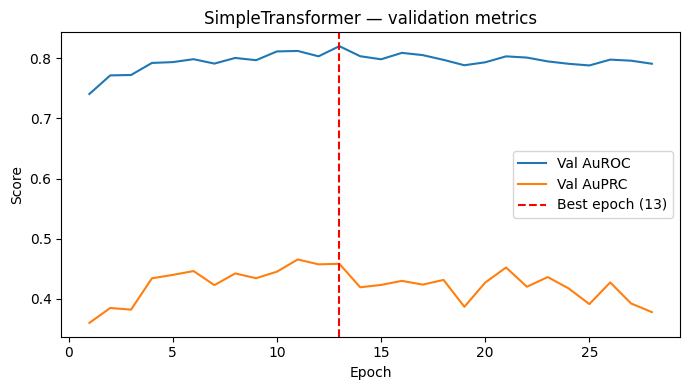


Model                               AuROC    AuPRC
----------------------------------------------------------
SimpleTransformer                  0.8225   0.4746


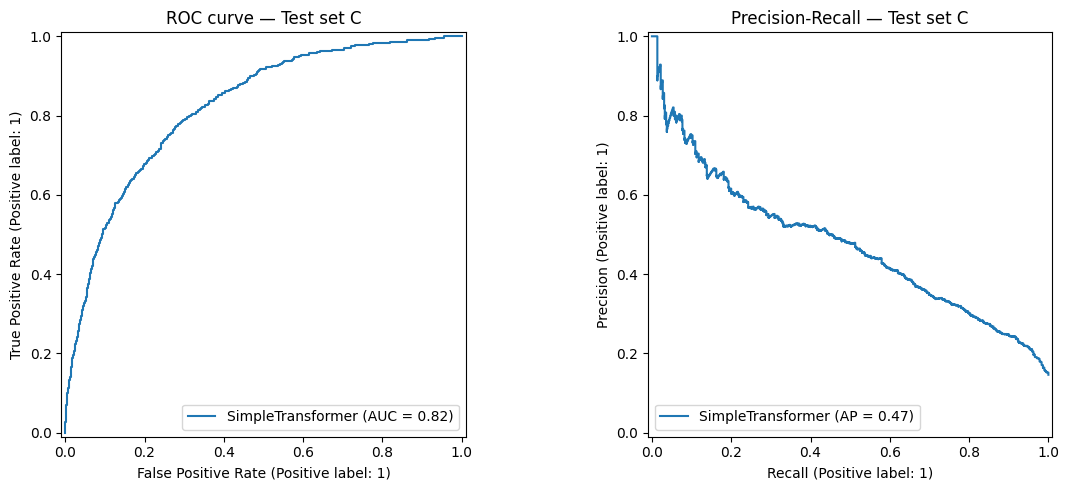

In [27]:
criterion_tf = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_tf = torch.optim.Adam(tf_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_val_auroc_tf = 0.0
best_epoch_tf = 0
best_state_tf = None
patience_count_tf = 0
history_tf = []

print(f"{'Epoch':>6}  {'Train loss':>10}  {'Val AuROC':>9}  {'Val AuPRC':>9}")
print("-" * 44)

for epoch in range(1, MAX_EPOCHS + 1):
    tf_model.train()
    total_loss = 0.0
    for X_b, y_b in train_loader:
        optimizer_tf.zero_grad()
        loss = criterion_tf(tf_model(X_b.to(DEVICE)), y_b.to(DEVICE))
        loss.backward()
        optimizer_tf.step()
        total_loss += loss.item() * len(y_b)

    val_auroc, val_auprc, _ = evaluate(tf_model, val_loader)
    avg_loss = total_loss / len(train_loader.dataset)
    history_tf.append(
        {
            "epoch": epoch,
            "loss": avg_loss,
            "val_auroc": val_auroc,
            "val_auprc": val_auprc,
        }
    )

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6}  {avg_loss:>10.4f}  {val_auroc:>9.4f}  {val_auprc:>9.4f}")

    if val_auroc > best_val_auroc_tf:
        best_val_auroc_tf = val_auroc
        best_epoch_tf = epoch
        best_state_tf = {k: v.clone() for k, v in tf_model.state_dict().items()}
        patience_count_tf = 0
    else:
        patience_count_tf += 1
        if patience_count_tf >= PATIENCE:
            print(
                f"\nEarly stop at epoch {epoch}  (no improvement for {PATIENCE} epochs)"
            )
            break

tf_model.load_state_dict(best_state_tf)
print(
    f"\nRestored best model — epoch {best_epoch_tf}  val AuROC={best_val_auroc_tf:.4f}"
)

# ── Training curve ─────────────────────────────────────────────────────────
hist_tf = pd.DataFrame(history_tf)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_tf["epoch"], hist_tf["val_auroc"], label="Val AuROC")
ax.plot(hist_tf["epoch"], hist_tf["val_auprc"], label="Val AuPRC")
ax.axvline(
    best_epoch_tf, color="red", linestyle="--", label=f"Best epoch ({best_epoch_tf})"
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_title("SimpleTransformer — validation metrics")
ax.legend()
plt.tight_layout()
plt.show()

# ── Results ────────────────────────────────────────────────────────────────
test_auroc_tf, test_auprc_tf, test_probs_tf = evaluate(tf_model, test_loader)

print("\n" + "=" * 58)
print(f"{'Model':<32}  {'AuROC':>7}  {'AuPRC':>7}")
print("-" * 58)
print(f"{'SimpleTransformer':<32}  {test_auroc_tf:>7.4f}  {test_auprc_tf:>7.4f}")
print("=" * 58)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(
    y_test.numpy(), test_probs_tf, name="SimpleTransformer", ax=axes[0]
)
PrecisionRecallDisplay.from_predictions(
    y_test.numpy(), test_probs_tf, name="SimpleTransformer", ax=axes[1]
)
axes[0].set_title("ROC curve — Test set C")
axes[1].set_title("Precision-Recall — Test set C")
plt.tight_layout()
plt.show()